# 02 - Week 1 Practical Detailed Solutions

Full clean solutions with instructor notes.


## Instructor Notes

- Emphasize interpretation after each output.
- Encourage students to check assumptions before inferential tests.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_iris
np.random.seed(42)
sns.set_theme(style="whitegrid")


## Data and Inspection


In [2]:
iris=load_iris(as_frame=True)
df=iris.frame.copy()
df["species"]=df["target"].map(dict(enumerate(iris.target_names)))
df=df.drop(columns=["target"])
display(df.head())
print(df.shape)
df.info()
display(df.describe())


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


(150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Interpretation: data are complete and balanced across classes.


## Full Descriptive Summary


In [3]:
num=df.select_dtypes(include="number").columns
summary=pd.DataFrame({"mean":df[num].mean(),"median":df[num].median(),"mode_first":df[num].mode().iloc[0],"variance":df[num].var(),"std":df[num].std(),"range":df[num].max()-df[num].min(),"skewness":df[num].apply(lambda x: stats.skew(x,bias=False))})
summary


,mean,median,mode_first,variance,std,range,skewness
sepal length (cm),5.843333,5.80,5.0,0.685694,0.828066,3.6,0.314911
sepal width (cm),3.057333,3.00,3.0,0.189979,0.435866,2.4,0.318966
petal length (cm),3.758000,4.35,1.4,3.116278,1.765298,5.9,-0.274884
petal width (cm),1.199333,1.30,0.2,0.581006,0.762238,2.4,-0.102967


## Visual and Correlation Review


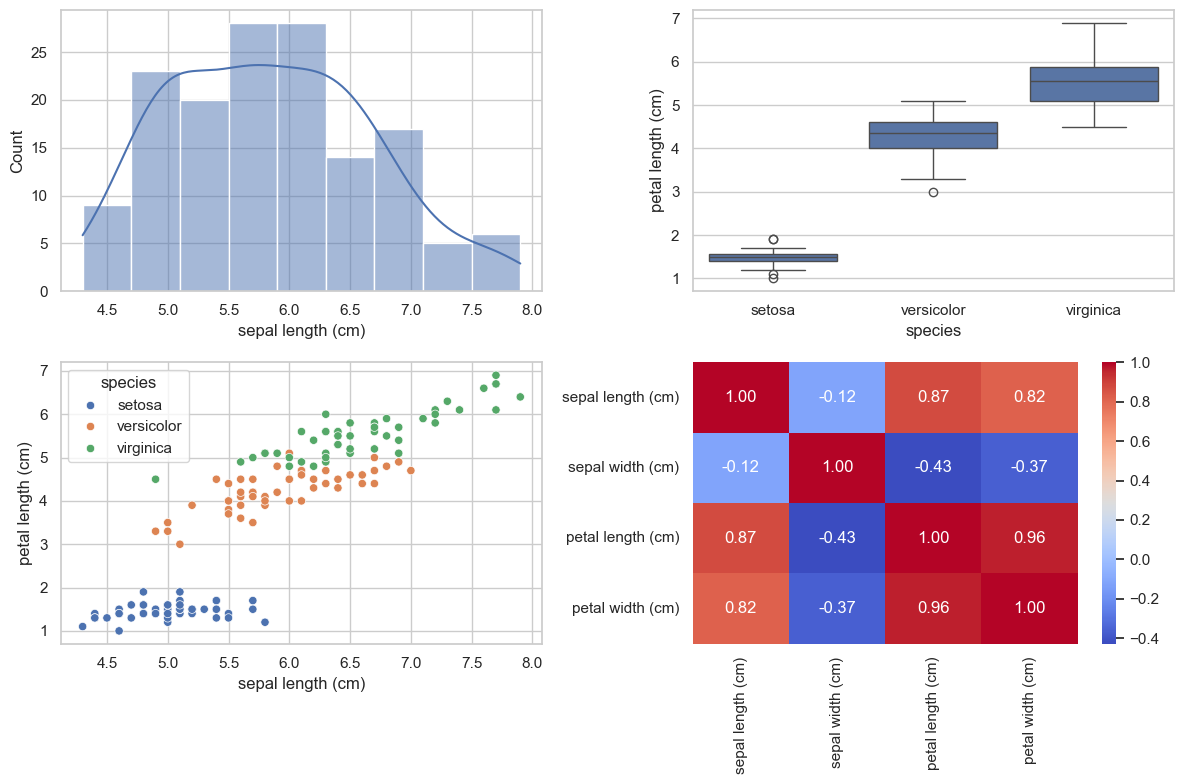

In [4]:
fig,axes=plt.subplots(2,2,figsize=(12,8))
sns.histplot(df["sepal length (cm)"],kde=True,ax=axes[0,0])
sns.boxplot(data=df,x="species",y="petal length (cm)",ax=axes[0,1])
sns.scatterplot(data=df,x="sepal length (cm)",y="petal length (cm)",hue="species",ax=axes[1,0])
sns.heatmap(df[num].corr(),annot=True,cmap="coolwarm",fmt=".2f",ax=axes[1,1])
plt.tight_layout(); plt.show()


Interpretation: petal variables are highly discriminative for species.


## CLT and Inference


In [5]:
pop=np.random.exponential(scale=2,size=150000)
def sm(n,reps=2000):
    return np.array([np.random.choice(pop,size=n,replace=True).mean() for _ in range(reps)])
m5,m30,m100=sm(5),sm(30),sm(100)
pd.DataFrame({"sample_size":[5,30,100],"mean_of_means":[m5.mean(),m30.mean(),m100.mean()],"std_of_means":[m5.std(),m30.std(),m100.std()]})


,sample_size,mean_of_means,std_of_means
0,5,2.031308,0.914385
1,30,2.004440,0.349412
2,100,1.990077,0.202155


In [6]:
t=stats.ttest_ind(df[df.species=="setosa"]["sepal length (cm)"],df[df.species=="versicolor"]["sepal length (cm)"],equal_var=False)
print("t-test:",t.statistic,t.pvalue)
a=stats.f_oneway(df[df.species=="setosa"]["petal length (cm)"],df[df.species=="versicolor"]["petal length (cm)"],df[df.species=="virginica"]["petal length (cm)"])
print("anova:",a.statistic,a.pvalue)


t-test: -10.52098626754911 3.746742613983842e-17
anova: 1180.161182252981 2.8567766109615584e-91


## Common Mistakes

1. Reporting only p-values without context.
2. Ignoring assumptions.
3. Confusing association with causation.

## Key Takeaway
Interpretation quality determines analysis quality.
